# Repetition Code of 3

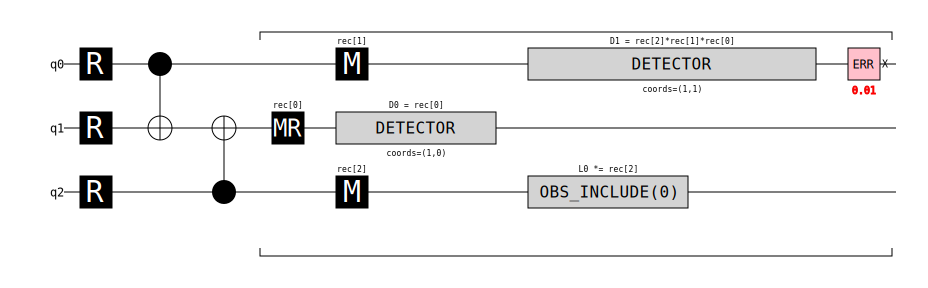

In [1]:
import stim
import numpy

circuit = stim.Circuit.generated(
    "repetition_code:memory", distance = 2, rounds = 1
)
circuit.append("X_ERROR", [0], 0.01)
circuit.diagram("timeline-svg")

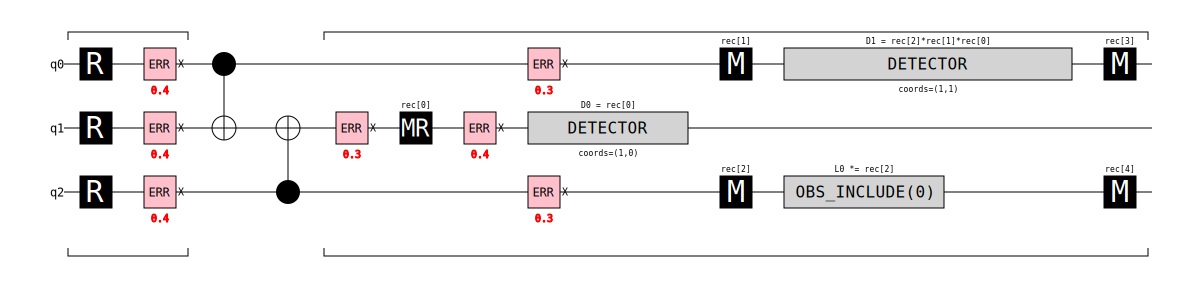

In [2]:
circuit1 = stim.Circuit.generated(
    "repetition_code:memory", distance = 2, rounds = 1,
    before_measure_flip_probability=0.3,
    after_reset_flip_probability=0.4,
)
#print(circuit1)
circuit1.append("M", [0, stim.target_inv(2)])
circuit1.diagram("timeline-svg")

# constructing self error model 

In [82]:
def b_m_p_insert(cirkit, b_m_p):
    new_cirkit = stim.Circuit()
    for i in range(len(cirkit)):
        if cirkit[i].name == "M" or cirkit[i].name == "MR":
            qubits = [t.value for t in cirkit[i].targets_copy() if t.is_qubit_target]
            if qubits:
                for q in qubits:
                    if b_m_p > np.random.random():
                        new_cirkit.append("X_ERROR", [q], 1)
        new_cirkit.append(cirkit[i])
    return new_cirkit

def a_r_p_insert(cirkit, a_r_p):
    new_cirkit = stim.Circuit()
    for part in cirkit:
        new_cirkit.append(part)
        if part.name in ("R", "MR"):
            qubits = [t.value for t in part.targets_copy() if t.is_qubit_target]
            for q in qubits:
                if np.random.random() < a_r_p:
                    new_cirkit.append("X_ERROR", [q], 1)
    return new_cirkit

In [83]:
import numpy as np
def error_channel(cirkit, before_measure_flip_probability, after_reset_flip_probability):
    b_m_p = before_measure_flip_probability
    a_r_p = after_reset_flip_probability
    new1 = b_m_p_insert(cirkit, b_m_p)
    new2 = a_r_p_insert(new1, a_r_p)
    return new2
    

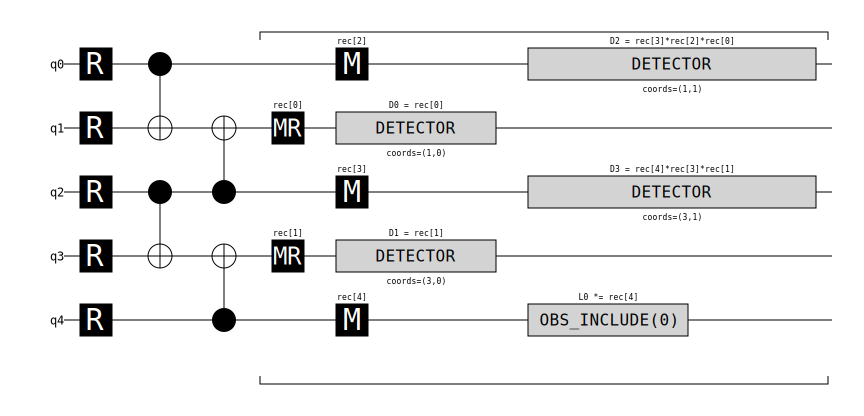

In [84]:
cirkit = stim.Circuit.generated("repetition_code:memory", distance = 3, rounds = 1)
cirkit.diagram("timeline-svg")

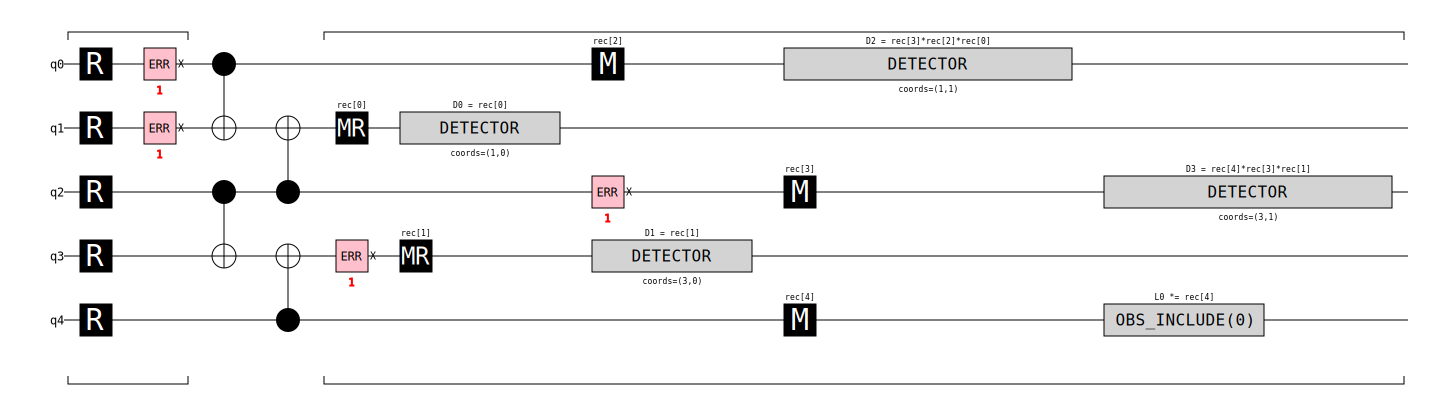

In [85]:
circuit_with_error = error_channel(cirkit, before_measure_flip_probability = 0.5, after_reset_flip_probability = 0.5)
circuit_with_error.diagram("timeline-svg")

In [7]:
m_sampler = circuit_with_error.compile_sampler()
measurements = m_sampler.sample(shots=1, bit_packed=False)

converter = circuit_with_error.compile_m2d_converter()
dets, obs = converter.convert(
    measurements=measurements,
    separate_observables=True,
)

print("measurements:", measurements)
print("dets:", dets)
print("obs:", obs)

measurements: [[ True False False False False]]
dets: [[False False False False]]
obs: [[False]]


## LUT Table for 3 qubit repetition code

In [47]:
lut = {
    (0, 0, 0, 0): (), (0, 0, 0, 1): (4,), (0, 0, 1, 0): (0,), (0, 0, 1, 1): (2,),
    (0, 1, 0, 0): (3,4,), (0, 1, 0, 1): (3,), (0, 1, 1, 0): (2,3,), (0, 1, 1, 1): (0,3,),
    (1, 0, 0, 0): (0,1,), (1, 0, 0, 1): (1,2), (1, 0, 1, 0): (1,), (1, 0, 1, 1): (1,4,),
    (1, 1, 0, 0): (1,2,3,), (1, 1, 0, 1): (0,1,3,), (1, 1, 1, 0): (1,3,4), (1, 1, 1, 1): (1,3),
}

data_correction = {(): (0,0,0), (4,): (0,0,1), (0,): (1,0,0), (2,): (0,1,0),
              (3,4,): (0,0,1), (3,): (0,0,0), (2,3,): (0,1,0) , (0,3,): (1,0,0),
              (0,1,): (1,0,0), (1,2): (0,1,0), (1,): (0,0,0), (1,4,): (0,0,1),
              (1,2,3,): (0,1,0), (0,1,3,): (1,0,0), (1,3,4): (0,0,1), (1,3): (0,0,0),
             }

In [48]:
def syndrome_to_tuple(det_row):
    return tuple(int(x) for x in det_row)

def lut_decode(det_row):
    s = syndrome_to_tuple(det_row)
    return lut.get(s, "UNKNOWN")

det_sampler = circuit_with_error.compile_detector_sampler()
detectors, observs = det_sampler.sample(shots=5, bit_packed=False,separate_observables=True)

for i, det_row in enumerate(detectors):
    print(f"shot {i}: syndrome={syndrome_to_tuple(det_row)} -> correction={lut_decode(det_row)}")

shot 0: syndrome=(0, 0, 0, 0) -> correction=()
shot 1: syndrome=(0, 0, 0, 0) -> correction=()
shot 2: syndrome=(0, 0, 0, 0) -> correction=()
shot 3: syndrome=(0, 0, 0, 0) -> correction=()
shot 4: syndrome=(0, 0, 0, 0) -> correction=()


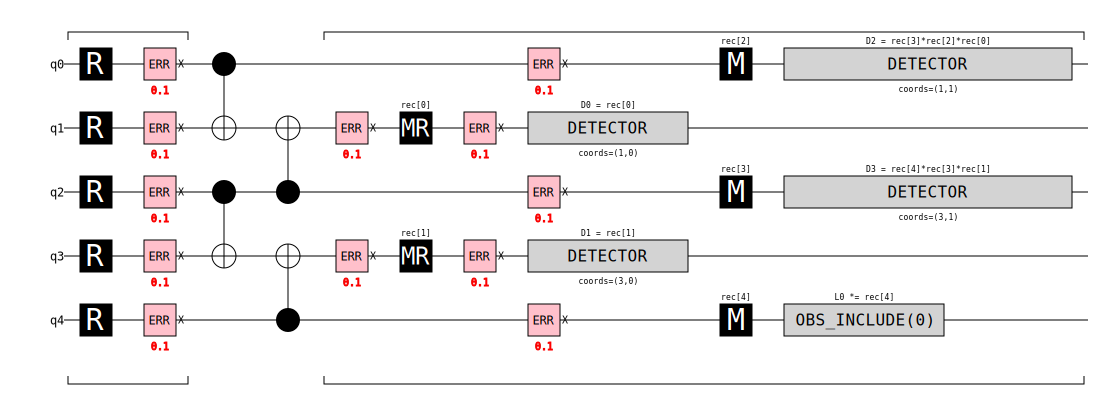

In [49]:
circuit = stim.Circuit.generated("repetition_code:memory",
                                 after_reset_flip_probability = 0.1,
                                 before_measure_flip_probability = 0.1,
                                 distance = 3, rounds = 1)
circuit.diagram("timeline-svg")

In [50]:
m_sampler = circuit.compile_sampler()
measurements = m_sampler.sample(shots=1, bit_packed=False)

converter = circuit.compile_m2d_converter()
dets, obs = converter.convert(
    measurements=measurements,
    separate_observables=True,
)

print("measurements:", measurements)
print("dets:", dets)
print("obs:", obs)

measurements: [[False False False False False]]
dets: [[False False False False]]
obs: [[False]]


In [52]:
shots = 100

m_sampler = circuit.compile_sampler()
measurements = m_sampler.sample(shots=shots, bit_packed=False)

converter = circuit.compile_m2d_converter()
dets, obs = converter.convert(
    measurements=measurements,
    separate_observables=True,
)

def row_str(row):
    return "".join(str(int(x)) for x in row)

def syndrome_to_tuple(det_row):
    return tuple(int(x) for x in det_row)

def lut_decode(det_row):
    return lut.get(syndrome_to_tuple(det_row), "Unknown")

print(f"{'shot':<6}{'measurements':<15}{'Qubits':<15}{'dets':<10}{'obs':<6}{'syndrome':<15}{'correction':<17}{'qubit correction'}")
print("-" * 100)
count = 0
for i in range(shots):
    syn = syndrome_to_tuple(dets[i])
    corr = lut_decode(dets[i])
    data_corr = data_correction.get(corr, None)
    corrected = int(row_str(measurements[i][2:5]))^int(row_str(data_corr))
    Logical = max(str(corrected))
    if Logical != row_str(obs[i]):
        print(
            f"{i:<6}"
            f"{row_str(measurements[i]):<15}"
            f"{row_str(measurements[i][2:5]):<15}"
            f"{row_str(dets[i]):<10}"
            f"{row_str(obs[i]):<6}"
            f"{str(syn):<15}"
            f"{str(corr):<17}"
            f"{row_str(data_corr)}"
        )
    elif Logical == row_str(obs[i]):
        count += 1


print(f"correction percentage: {count/shots*100}")

shot  measurements   Qubits         dets      obs   syndrome       correction       qubit correction
----------------------------------------------------------------------------------------------------
3     10001          001            1011      1     (1, 0, 1, 1)   (1, 4)           001
4     10110          110            1011      0     (1, 0, 1, 1)   (1, 4)           001
19    01001          001            0100      1     (0, 1, 0, 0)   (3, 4)           001
29    00001          001            0001      1     (0, 0, 0, 1)   (4,)             001
33    01001          001            0100      1     (0, 1, 0, 0)   (3, 4)           001
41    01001          001            0100      1     (0, 1, 0, 0)   (3, 4)           001
47    00001          001            0001      1     (0, 0, 0, 1)   (4,)             001
63    01001          001            0100      1     (0, 1, 0, 0)   (3, 4)           001
67    00001          001            0001      1     (0, 0, 0, 1)   (4,)             001
83    

### Rough work done for verification of LUT and writting LUT in systemVerilog

In [34]:
errors = [list(v) for v in product([0, 1], repeat=5)]
syndromes = []
for e in errors:
    syndrome = list((e[1], e[3], e[0]^e[1]^e[2], e[2]^e[3]^e[4]))
    syndromes.append(syndrome)

In [39]:
lut_dict = {}
for i in range(len(syndromes)):
    for j in range(len(syndromes)):
        if i != j and syndromes[i] == syndromes[j]:
            lut_dict[str(syndromes[i])] = (errors[i], errors[j])
lut_dict

{'[0, 0, 0, 0]': ([1, 0, 1, 0, 1], [0, 0, 0, 0, 0]),
 '[0, 0, 0, 1]': ([1, 0, 1, 0, 0], [0, 0, 0, 0, 1]),
 '[0, 1, 0, 1]': ([1, 0, 1, 1, 1], [0, 0, 0, 1, 0]),
 '[0, 1, 0, 0]': ([1, 0, 1, 1, 0], [0, 0, 0, 1, 1]),
 '[0, 0, 1, 1]': ([1, 0, 0, 0, 1], [0, 0, 1, 0, 0]),
 '[0, 0, 1, 0]': ([1, 0, 0, 0, 0], [0, 0, 1, 0, 1]),
 '[0, 1, 1, 0]': ([1, 0, 0, 1, 1], [0, 0, 1, 1, 0]),
 '[0, 1, 1, 1]': ([1, 0, 0, 1, 0], [0, 0, 1, 1, 1]),
 '[1, 0, 1, 0]': ([1, 1, 1, 0, 1], [0, 1, 0, 0, 0]),
 '[1, 0, 1, 1]': ([1, 1, 1, 0, 0], [0, 1, 0, 0, 1]),
 '[1, 1, 1, 1]': ([1, 1, 1, 1, 1], [0, 1, 0, 1, 0]),
 '[1, 1, 1, 0]': ([1, 1, 1, 1, 0], [0, 1, 0, 1, 1]),
 '[1, 0, 0, 1]': ([1, 1, 0, 0, 1], [0, 1, 1, 0, 0]),
 '[1, 0, 0, 0]': ([1, 1, 0, 0, 0], [0, 1, 1, 0, 1]),
 '[1, 1, 0, 0]': ([1, 1, 0, 1, 1], [0, 1, 1, 1, 0]),
 '[1, 1, 0, 1]': ([1, 1, 0, 1, 0], [0, 1, 1, 1, 1])}

In [41]:
lut_dict_min = {}
for i in range(len(syndromes)):
    for j in range(len(syndromes)):
        if i != j and syndromes[i] == syndromes[j]:
            if sum(errors[i]) != sum(errors[j]):
                lut_dict_min[str(syndromes[i])] = min([errors[i], errors[j]], key = sum)
            else:
                lut_dict_min[str(syndromes[i])] = "check"
lut_dict_min

{'[0, 0, 0, 0]': [0, 0, 0, 0, 0],
 '[0, 0, 0, 1]': [0, 0, 0, 0, 1],
 '[0, 1, 0, 1]': [0, 0, 0, 1, 0],
 '[0, 1, 0, 0]': [0, 0, 0, 1, 1],
 '[0, 0, 1, 1]': [0, 0, 1, 0, 0],
 '[0, 0, 1, 0]': [1, 0, 0, 0, 0],
 '[0, 1, 1, 0]': [0, 0, 1, 1, 0],
 '[0, 1, 1, 1]': [1, 0, 0, 1, 0],
 '[1, 0, 1, 0]': [0, 1, 0, 0, 0],
 '[1, 0, 1, 1]': [0, 1, 0, 0, 1],
 '[1, 1, 1, 1]': [0, 1, 0, 1, 0],
 '[1, 1, 1, 0]': [0, 1, 0, 1, 1],
 '[1, 0, 0, 1]': [0, 1, 1, 0, 0],
 '[1, 0, 0, 0]': [1, 1, 0, 0, 0],
 '[1, 1, 0, 0]': [0, 1, 1, 1, 0],
 '[1, 1, 0, 1]': [1, 1, 0, 1, 0]}

In [53]:
lut_dict_min = {}
for i in range(len(syndromes)):
    for j in range(len(syndromes)):
        if i != j and syndromes[i] == syndromes[j]:
            if sum(errors[i]) != sum(errors[j]):
                k = min([errors[i], errors[j]], key = sum)
                lut_dict_min[str(syndromes[i])] = k[0:5:2]
            else:
                lut_dict_min[str(syndromes[i])] = "check"
lut_dict_min

{'[0, 0, 0, 0]': [0, 0, 0],
 '[0, 0, 0, 1]': [0, 0, 1],
 '[0, 1, 0, 1]': [0, 0, 0],
 '[0, 1, 0, 0]': [0, 0, 1],
 '[0, 0, 1, 1]': [0, 1, 0],
 '[0, 0, 1, 0]': [1, 0, 0],
 '[0, 1, 1, 0]': [0, 1, 0],
 '[0, 1, 1, 1]': [1, 0, 0],
 '[1, 0, 1, 0]': [0, 0, 0],
 '[1, 0, 1, 1]': [0, 0, 1],
 '[1, 1, 1, 1]': [0, 0, 0],
 '[1, 1, 1, 0]': [0, 0, 1],
 '[1, 0, 0, 1]': [0, 1, 0],
 '[1, 0, 0, 0]': [1, 0, 0],
 '[1, 1, 0, 0]': [0, 1, 0],
 '[1, 1, 0, 1]': [1, 0, 0]}

In [80]:
for key in product([0, 1], repeat=4):
    syndrom = row_str(key)
    ki  = str(list(key))
    expc = row_str(lut_dict_min[ki])
    print(f"4'b{syndrom}: correction = 3'b{expc};")

4'b0000: correction = 3'b000;
4'b0001: correction = 3'b001;
4'b0010: correction = 3'b100;
4'b0011: correction = 3'b010;
4'b0100: correction = 3'b001;
4'b0101: correction = 3'b000;
4'b0110: correction = 3'b010;
4'b0111: correction = 3'b100;
4'b1000: correction = 3'b100;
4'b1001: correction = 3'b010;
4'b1010: correction = 3'b000;
4'b1011: correction = 3'b001;
4'b1100: correction = 3'b010;
4'b1101: correction = 3'b100;
4'b1110: correction = 3'b001;
4'b1111: correction = 3'b000;
